Name :- Akshit Negi

CU24250214

BTech CSE 3rd Year SECTION - "B"

Roll No. :- 4

Experiment No. 4

Experiment Name :

Frequency Domain Image Filtering using Fourier Transform

Aim:

To implement image filtering in the frequency domain using the Fourier transform and analyze the effectiveness of frequency-based filtering techniques for noise removal, image enhancement, and feature preservation using Python and OpenCV.

**Step1->Import the required libraries and load a grayscale image for processing.**

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Please upload a grayscale or color image for processing:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print(f"Successfully loaded '{image_path}' with dimensions: {img.shape}")

Please upload a grayscale or color image for processing:


Saving Screenshot 2026-03-12 183308.png to Screenshot 2026-03-12 183308.png
Successfully loaded 'Screenshot 2026-03-12 183308.png' with dimensions: (819, 1901)


**Step2->  Compute the Discrete Fourier Transform (DFT) of the image using OpenCV or NumPy.**

In [5]:
# Compute 2D DFT using Fast Fourier Transform (FFT)
dft = np.fft.fft2(img.astype(np.float32))

**Step3-> Shift the zero-frequency component to the center of the frequency spectrum for visualization.**

In [6]:
# Shift low-frequency (DC) components to the center of the spectrum
dft_shifted = np.fft.fftshift(dft)

**Step4-> Display and analyze the magnitude spectrum of the transformed image.**

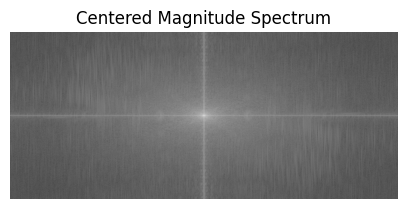

In [7]:
# Calculate magnitude spectrum and scale logarithmically for visualization
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)

plt.figure(figsize=(5, 5))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Centered Magnitude Spectrum')
plt.axis('off')
plt.show()

**Step5-> Design and apply a Low-Pass Frequency Filter to suppress high-frequency components and reduce image noise.**

In [8]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2  # Center coordinates

# Create Ideal Low-Pass Filter mask (Radius D0)
D0 = 40
x, y = np.ogrid[:rows, :cols]
distance = np.sqrt((x - crow)**2 + (y - ccol)**2)

lpf_mask = np.zeros((rows, cols), dtype=np.float32)
lpf_mask[distance <= D0] = 1.0

# Apply filter mask to frequency domain
lpf_dft = dft_shifted * lpf_mask

**Step6-> Design and apply a High-Pass Frequency Filter to suppress low-frequency components and enhance edges and fine details.**

In [9]:
# Create Ideal High-Pass Filter mask (Invert LPF mask)
hpf_mask = 1.0 - lpf_mask

# Apply filter mask to frequency domain
hpf_dft = dft_shifted * hpf_mask

**Step7-> Perform the Inverse Fourier Transform (IDFT) to reconstruct the filtered images in the spatial domain.**

In [10]:
# Inverse shift and Inverse FFT for Low-Pass Filter
lpf_ishift = np.fft.ifftshift(lpf_dft)
img_lpf = np.abs(np.fft.ifft2(lpf_ishift))

# Inverse shift and Inverse FFT for High-Pass Filter
hpf_ishift = np.fft.ifftshift(hpf_dft)
img_hpf = np.abs(np.fft.ifft2(hpf_ishift))

**Step8-> Compare the original image, frequency spectrum, low-pass filtered image, and high pass filtered image.**

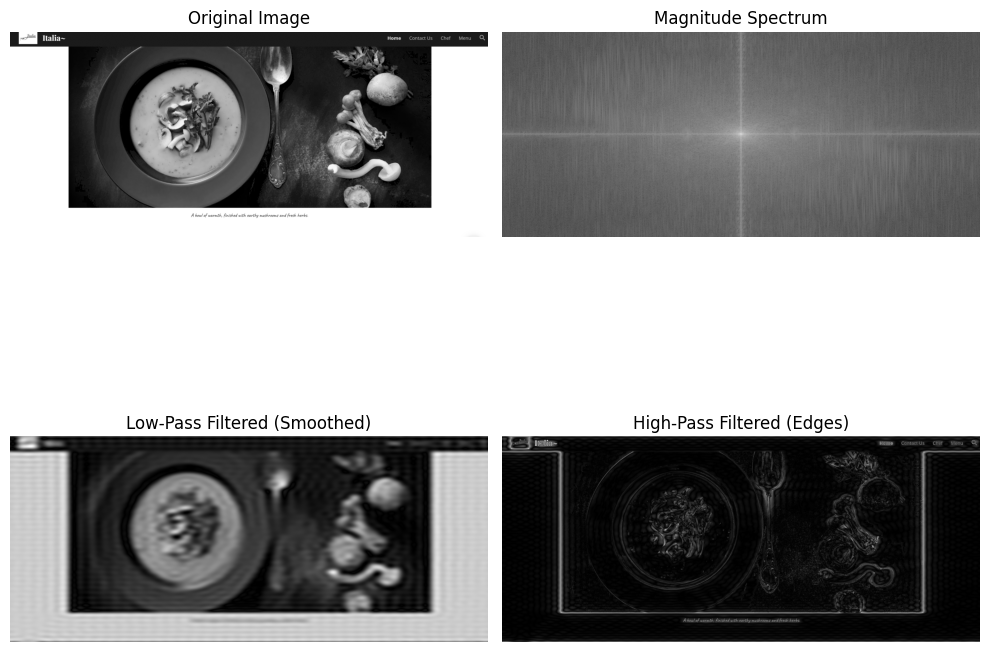

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image')

axes[0, 1].imshow(magnitude_spectrum, cmap='gray')
axes[0, 1].set_title('Magnitude Spectrum')

axes[1, 0].imshow(img_lpf, cmap='gray')
axes[1, 0].set_title('Low-Pass Filtered (Smoothed)')

axes[1, 1].imshow(img_hpf, cmap='gray')
axes[1, 1].set_title('High-Pass Filtered (Edges)')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

#Question / Answer

### **1. What is the Fourier Transform? Why is it important in digital image processing?**

The Fourier Transform is a mathematical technique that decomposes an image into its constituent sine and cosine frequencies. In image processing, it converts an image from the spatial domain (pixel coordinates) to the frequency domain (rate of intensity change). It is important because complex spatial operations—such as convolution, periodic noise removal, and blur reduction—become simple point-by-point algebraic operations in the frequency domain.

### **2. Differentiate between the spatial domain and the frequency domain.**

*   **Spatial Domain:** Directly manipulates pixel intensity values based on their physical coordinate positions (x,y) using operations like matrix convolution or thresholding.
*   **Frequency Domain:** Manipulates the rate at which pixel intensities change across the image (u,v). Low frequencies correspond to smooth regions and background, while high frequencies correspond to sharp transitions, fine details, and edges.

### **3. What is the significance of the Discrete Fourier Transform (DFT) in image processing?**

Since digital images consist of discrete pixels rather than continuous signals, the DFT provides the discrete mathematical framework needed to compute frequency representations. Utilizing the Fast Fourier Transform (FFT) algorithm, DFT reduces the computational complexity from O(N²) to O(NlogN), enabling efficient real-time frequency analysis, filtering, and image compression (such as JPEG).

### **4. Explain the purpose of shifting the zero-frequency component to the center of the frequency spectrum.**

By default, the zero-frequency component F(0,0)—which represents the average DC brightness of the image—is located at the top-left corner of the Fourier spectrum. Shifting F(0,0) to the center (N/2,M/2) using the transformation (−1)^(x+y) places low frequencies at the middle and high frequencies toward the outer edges. This creates a symmetrical, intuitive layout that simplifies filter design (e.g., circular low-pass or high-pass masks).

### **5. Compare Low-Pass Frequency Filters and High-Pass Frequency Filters with suitable applications.**

*   **Low-Pass Filters (LPF):** Pass low-frequency components while attenuating high frequencies. They smooth sharp intensity transitions to reduce noise and apply Gaussian blur (e.g., removing sensor noise or preparing images for downsampling).
*   **High-Pass Filters (HPF):** Pass high-frequency components while suppressing low frequencies. They attenuate uniform background areas to highlight sharp intensity changes (e.g., edge detection, structural outline extraction, and image sharpening).

### **6. What is the role of the Inverse Fourier Transform (IDFT) in image reconstruction?**

After an image's frequency spectrum is modified using a frequency filter mask H(u,v), the result remains in the frequency domain G(u,v)=F(u,v)⋅H(u,v). The IDFT converts this filtered frequency representation back into a viewable 2D spatial pixel matrix g(x,y), completing the spatial-frequency-spatial processing pipeline.

### **7. Why is frequency domain filtering preferred for certain image enhancement tasks?**

Frequency domain filtering excels at isolating and suppressing global or periodic patterns—such as electrical interference, scanning lines, or regular grain noise—that are extremely difficult to separate in the spatial domain. It also makes large-kernel convolutions far computationally cheaper via the Convolution Theorem.

### **8. Mention four real-world applications where Fourier Transform is used in computer vision and image analysis.**

1.  **Image Compression:** Core foundation for algorithms like JPEG and MPEG to discard visually imperceptible high frequencies.
2.  **Periodic Noise Removal:** Eliminating recurring line artifacts or mesh patterns in scanned prints and satellite photos using notch filters.
3.  **Medical MRI Reconstruction:** Converting raw frequency-domain k-space data gathered by MRI scanners into clear spatial anatomical scans.
4.  **Optical Character Recognition (OCR):** Pattern matching and rotation-invariant feature extraction via frequency domain correlation.

### **9. Compare frequency domain filtering with spatial domain filtering based on computational efficiency and practical applications.**

| Parameter                  | Spatial Domain Filtering                                       | Frequency Domain Filtering                                                              |
| :------------------------- | :------------------------------------------------------------- | :-------------------------------------------------------------------------------------- |
| **Computational Efficiency** | Faster for small filter kernels (3×3, 5×5) via direct convolution. | Faster for large filter kernels due to O(NlogN) FFT complexity versus O(N²M²) spatial convolution. |
| **Implementation**         | Direct pixel neighborhood operations (e.g., Sobel, Median filter). | Multiplying spectrum by a mask, then applying IDFT.                                     |
| **Primary Applications**   | Real-time local blurring, edge detection, and fast noise reduction. | Global noise removal, periodic artifact removal, deblurring, and image compression.     |

### **10. How does frequency domain filtering improve the performance of image restoration and feature extraction techniques?**

For image restoration, techniques like Wiener filtering operate in the frequency domain to invert known degradation functions (such as motion blur or lens defocus) while simultaneously suppressing additive noise. For feature extraction, frequency filtering allows models to selectively isolate structural boundaries or specific directional textures while stripping away global illumination changes and high-frequency sensor clutter.